1️⃣ Install & Import Libraries

In [1]:
!pip install yfinance statsmodels seaborn

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import coint
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

2️⃣ Define Stock Universe

In [182]:
tickers = [
"AAPL","MSFT","NVDA","AMD","INTC",
"GOOG","META","ORCL","CRM","ADBE",
"CSCO","IBM","QCOM","TXN","AMAT",
"MU","PANW","SNOW","NOW","SHOP",
"AVGO","TSM","ASML","INTU","PLTR",
"ANET","LRCX","KLAC","MRVL","MCHP",
"ADI","NXPI","MPWR","SWKS","QRVO",
"TER","ON","STM","WDC","STX",
"DELL","HPQ","HPE","NTAP","SMCI",
"CRWD","ZS","OKTA","FTNT","NET",
"DDOG","TEAM","SPLK","WDAY","DOCU",
"BILL","SQ","PYPL","ROKU",
"UBER","LYFT","SNAP","PINS","RBLX",
"EA","TTWO","U","APP","ZI","BABA"
]


70

3️⃣ Download Data

In [183]:
data = yf.download(
    tickers,
    start="2018-01-01",
    end="2024-01-01",
    group_by="ticker",
    threads=True
)

data = data.xs("Close", level=1, axis=1)

data = data.dropna(axis=1)
data.head()

/tmp/ipykernel_551/2565517459.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  70 of 70 completed
ERROR:yfinance:
3 Failed downloads:
ERROR:yfinance:['SPLK', 'SQ', 'ZI']: YFTzMissingError('possibly delisted; no timezone found')


Ticker,DELL,PANW,PYPL,TXN,CSCO,SHOP,MPWR,EA,ON,NVDA,...,AVGO,SWKS,INTC,STM,WDC,QCOM,MCHP,SNAP,LRCX,ADBE
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,21.114550,24.758333,73.447319,83.807091,30.433558,10.549,108.942368,106.316971,21.809999,4.928266,...,21.130898,81.222839,39.330391,20.829403,56.182060,52.614017,38.735165,14.95,16.871248,177.699997
2018-01-03,21.337400,24.946667,76.341843,86.077515,30.676336,10.775,110.993660,106.608391,22.780001,5.252615,...,21.361988,82.460625,37.995586,21.340843,57.072632,53.211178,39.317844,15.31,17.158260,181.039993
2018-01-04,21.716507,24.876667,76.321953,85.966385,30.763124,10.995,112.023956,104.121643,22.780001,5.280303,...,21.369101,83.153793,37.298801,21.768587,56.727451,53.283810,39.412102,14.59,17.236696,183.220001
2018-01-05,21.875320,25.495001,78.281471,86.625290,31.189177,11.058,112.464203,109.172806,22.830000,5.325049,...,21.495728,83.533356,37.559040,21.703493,57.086433,53.638870,39.527767,14.50,17.505882,185.339996
2018-01-08,21.870190,25.608334,78.629616,87.038094,31.512663,11.235,113.859795,109.979050,22.969999,5.488213,...,21.547167,83.549866,37.559040,21.554714,56.223480,53.477474,39.682014,14.06,17.637804,185.039993


4️⃣ Split Data

We separate training vs testing.

Training = find pairs

Testing = simulate trades

In [184]:
train = data[:'2022']
test = data['2022':]

5️⃣ Correlation Matrix

Finding Higher Correlation Pairs

In [185]:
corr_matrix = train.corr()

pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1,len(corr_matrix.columns)):

        if corr_matrix.iloc[i,j] > 0.98:

            pairs.append((corr_matrix.columns[i],
                          corr_matrix.columns[j],
                          corr_matrix.iloc[i,j]))

pairs

[('TXN', 'ADI', np.float64(0.9811931892036884)),
 ('AMAT', 'NXPI', np.float64(0.9829293316387518)),
 ('TER', 'LRCX', np.float64(0.9808545935442124))]

6️⃣ Cointegration Test

In [186]:
cointegrated_pairs = []

for s1,s2,_ in pairs:

    score,pvalue,_ = coint(train[s1],train[s2])

    if pvalue < 0.05:

        cointegrated_pairs.append((s1,s2,pvalue))

cointegrated_pairs

[('AMAT', 'NXPI', np.float64(0.00017129926863625314)),
 ('TER', 'LRCX', np.float64(0.021714658812968416))]

7️⃣ Hedge Ratio

In [170]:
stock1 = cointegrated_pairs[0][0]
stock2 = cointegrated_pairs[0][1]

X = train[stock2]
Y = train[stock1]

X = sm.add_constant(X)

model = sm.OLS(Y,X).fit()

beta = model.params[1]

beta

/tmp/ipykernel_551/480041872.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


np.float64(0.8567274381749642)

8️⃣ Spread Calculation

Text(0.5, 1.0, 'Spread')

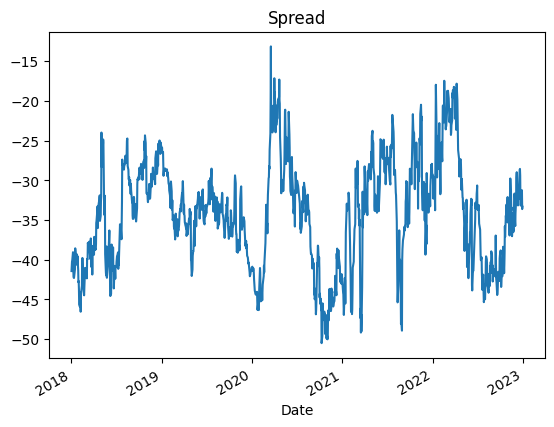

In [171]:
spread = train[stock1] - beta * train[stock2]

spread.plot()
plt.title("Spread")

9️⃣ ADF Test

p < 0.05 → stationary spread

In [172]:
result = adfuller(spread)

print("ADF p-value:",result[1])

ADF p-value: 2.3364361115402445e-05


🔟 Z-Score Signal

In [173]:
window = 20

rolling_mean = spread.rolling(window).mean()
rolling_std = spread.rolling(window).std()

zscore = (spread - rolling_mean) / rolling_std

PLOT:

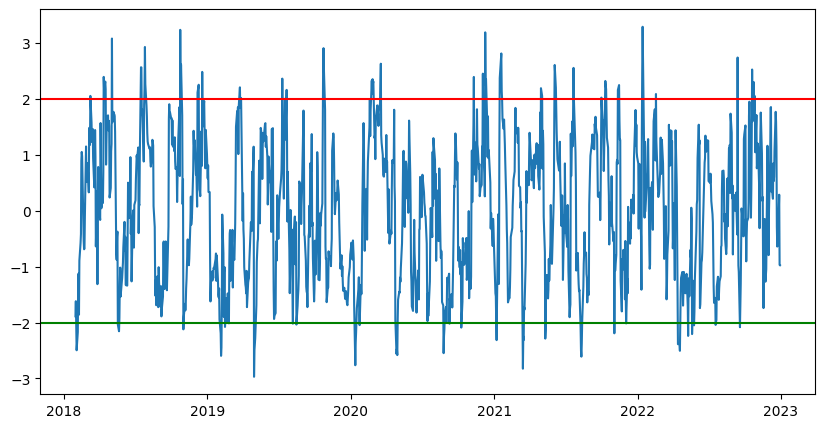

In [174]:
plt.figure(figsize=(10,5))
plt.plot(zscore)
plt.axhline(2,color='red')
plt.axhline(-2,color='green')
plt.show()

1️⃣1️⃣ Half-Life

In [175]:
spread_lag = spread.shift(1)
spread_ret = spread - spread_lag

spread_lag = spread_lag.dropna()
spread_ret = spread_ret.dropna()

spread_lag2 = sm.add_constant(spread_lag)

model = sm.OLS(spread_ret,spread_lag2).fit()

beta = model.params.iloc[1]

half_life = -np.log(2)/beta

print("Half-life:",round(half_life,2))

Half-life: 16.18


1️⃣2️⃣ Backtest

In [176]:
spread_test = test[stock1] - beta * test[stock2]

mean = spread_test.rolling(20).mean()
std = spread_test.rolling(20).std()

zscore = (spread_test - mean)/std

Trading Rules

In [177]:
positions = []

for z in zscore:

    if z > 2:
        positions.append(-1)   # short

    elif z < -2:
        positions.append(1)    # long

    else:
        positions.append(0)

Strategy Returns

<Axes: title={'center': 'Equity Curve'}, xlabel='Date'>

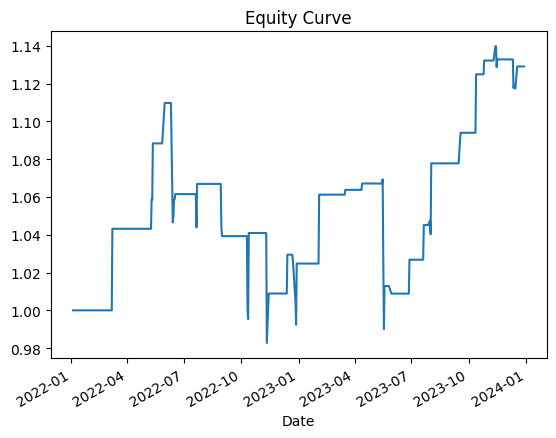

In [178]:
returns1 = test[stock1].pct_change()
returns2 = test[stock2].pct_change()

spread_returns = returns1 - beta * returns2
spread_returns = spread_returns.dropna()

positions = pd.Series(positions, index=zscore.index)
positions = positions.shift(1)

positions = positions.loc[spread_returns.index]

strategy_returns = positions * spread_returns

equity = (1 + strategy_returns).cumprod()

equity.plot(title="Equity Curve")

1️⃣3️⃣ Performance Metrics

In [179]:
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)

print("Sharpe Ratio:",sharpe)

Sharpe Ratio: 0.596881051856148
